# Problem Sets — Solutions

This notebook contains complete solutions for all 18 problems.  
Run the **Setup** cell first; cells within each problem set must be run in order.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from scipy import integrate, special
from functools import lru_cache

import gw_turbulence.core as ref
from gw_turbulence.mpi import split_row_indices as ref_split

print("Setup complete.")

Setup complete.


---
## Problem Set 1 — Foundations

### P1.1 Solution: The Geometric Kernel

$$B(p,x,y)=54 - 2p^2 x^{3/2} - 2p^2 y^{3/2} + p^4 x^{3/2}y^{3/2} + x^{-3/2}y^{3/2} + y^{-3/2}x^{3/2}$$

**Verification by hand:**  
- $B(0,1,1) = 54 + 1 + 1 = 56$ ✓  
- $B(1,1,1) = 54 - 2 - 2 + 1 + 1 + 1 = 53$ ✓

In [2]:
def my_kernel_bracket(p: float, x: float, y: float) -> float:
    xp32 = x ** 1.5
    yp32 = y ** 1.5
    return (
        54.0
        - 2.0 * p**2 * xp32
        - 2.0 * p**2 * yp32
        + p**4 * xp32 * yp32
        + x**(-1.5) * yp32
        + y**(-1.5) * xp32
    )

In [3]:
# --- P1.1 Verification ---
assert abs(my_kernel_bracket(0, 1, 1) - 56.0) < 1e-10
assert abs(my_kernel_bracket(1, 1, 1) - 53.0) < 1e-10

for p, x, y in [(0.5, 0.8, 1.2), (1.0, 0.5, 2.0), (1.5, 1.0, 0.3)]:
    assert abs(my_kernel_bracket(p, x, y) - ref.kernel_bracket(p, x, y)) < 1e-10

print("P1.1 passed!")

P1.1 passed!


### P1.2 Solution: Monochromatic Geometric Kernel $K_0(p)$

$$K_0(p) = \frac{14}{3} - \frac{p^2}{3} + \frac{p^4}{12}$$

**Analytical notes:**
- $K_0(0) = 14/3$: the isotropic tensor average when source and GW are at the same scale
- $K_0(2) = 14/3 - 4/3 + 16/12 = 14/3 - 4/3 + 4/3 = 14/3 \approx 4.667$ — not zero at the triangle boundary
- Maximum is at $p=0$ since $dK_0/dp = -2p/3 + p^3/3 = 0 \Rightarrow p = 0$ or $p = \sqrt{2}$; the maximum is at $p=0$

In [4]:
def my_K0_p(p: float) -> float:
    return 14.0 / 3.0 - p**2 / 3.0 + p**4 / 12.0

K0(0) = 4.666667  (= 14/3 = 4.666667)
K0(2) = 4.666667  (= 14/3 = 4.666667, not zero)


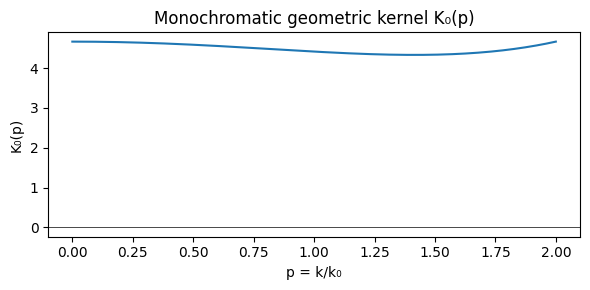

K0 maximum at p = 0.000
P1.2 passed!


In [5]:
# --- P1.2 Verification ---
assert abs(my_K0_p(0) - 14/3) < 1e-12
for p_test in [0.0, 0.5, 1.0, 1.5, 2.0]:
    assert abs(my_K0_p(p_test) - ref.K0_p(p_test)) < 1e-12

print(f"K0(0) = {my_K0_p(0):.6f}  (= 14/3 = {14/3:.6f})")
print(f"K0(2) = {my_K0_p(2):.6f}  (= 14/3 = {14/3:.6f}, not zero)")

p_arr = np.linspace(0, 2, 300)
K0_arr = np.vectorize(my_K0_p)(p_arr)
plt.figure(figsize=(6, 3))
plt.plot(p_arr, K0_arr)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('p = k/k₀'); plt.ylabel('K₀(p)')
plt.title('Monochromatic geometric kernel K₀(p)')
plt.tight_layout(); plt.show()
print(f"K0 maximum at p = {p_arr[np.argmax(K0_arr)]:.3f}")
print("P1.2 passed!")

### P1.3 Solution: Kraichnan Decorrelation Kernel

$$H(p,\Omega) = \frac{K_0(p)}{p}\,\Theta(2-p)\,\exp\!\left(-\frac{\Omega^2}{2\pi}\right)$$

**Triangle inequality:** with $k_1 = u = k_0$, the constraint $|k_1 - u| \leq k \leq k_1 + u$ gives $0 \leq k \leq 2k_0$, i.e., $p \leq 2$.

**Characteristic frequency:** $H$ drops to $e^{-1}$ when $\Omega^2/(2\pi) = 1$, so $\Omega^* = \sqrt{2\pi} \approx 2.507$.

In [6]:
def my_H_delta_k_kraichnan(p, Omega):
    p = np.asarray(p, dtype=float)
    Omega = np.asarray(Omega, dtype=float)
    result = np.where(
        (p > 0) & (p <= 2.0),
        my_K0_p(p) / np.maximum(p, 1e-30) * np.exp(-Omega**2 / (2.0 * np.pi)),
        0.0,
    )
    return float(result) if result.ndim == 0 else result

Characteristic frequency Ω* = √(2π) = 2.5066


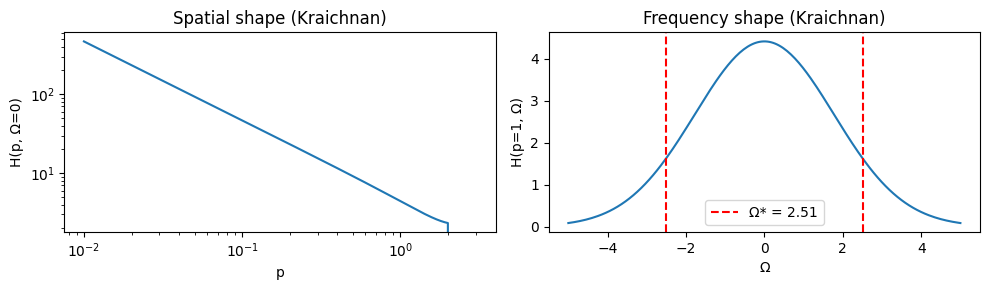

P1.3 passed!


In [38]:
# --- P1.3 Verification ---
assert my_H_delta_k_kraichnan(2.5, 0.0) == 0.0
assert my_H_delta_k_kraichnan(-1.0, 0.0) == 0.0
assert my_H_delta_k_kraichnan(1.0, 0.0) > 0

p_arr  = np.linspace(0.01, 3.0, 200)
Om_arr = np.linspace(-5, 5, 200)
assert np.allclose(my_H_delta_k_kraichnan(p_arr, 0.0),  ref.H_delta_k_kraichnan(p_arr, 0.0),  rtol=1e-10)
assert np.allclose(my_H_delta_k_kraichnan(1.0, Om_arr), ref.H_delta_k_kraichnan(1.0, Om_arr), rtol=1e-10)

Omega_star = np.sqrt(2 * np.pi)
print(f"Characteristic frequency Ω* = √(2π) = {Omega_star:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].loglog(p_arr, my_H_delta_k_kraichnan(p_arr, 0.0))
axes[0].set_xlabel('p'); axes[0].set_ylabel('H(p, Ω=0)')
axes[0].set_title('Spatial shape (Kraichnan)')
axes[1].plot(Om_arr, my_H_delta_k_kraichnan(1.0, Om_arr))
axes[1].axvline( Omega_star, color='r', ls='--', label=f'Ω* = {Omega_star:.2f}')
axes[1].axvline(-Omega_star, color='r', ls='--')
axes[1].set_xlabel('Ω'); axes[1].set_ylabel('H(p=1, Ω)')
axes[1].set_title('Frequency shape (Kraichnan)')
axes[1].legend()
plt.tight_layout(); plt.show()
print("P1.3 passed!")

---
## Problem Set 2 — Integration Infrastructure

### P2.1 Solution: Integration Bounds

Given $x = (k_1/k_0)^{-4/3}$, so $\tilde{k}_1 = x^{-3/4}$. Triangle inequality gives $u \in [\max(|\tilde{k}_1-p|,1),\;\min(\tilde{k}_1+p,R^{3/4})]$, then $y = u^{-4/3}$ reverses the ordering: $y_{\min} = u_{\max}^{-4/3}$, $y_{\max} = u_{\min}^{-4/3}$.

In [8]:
def my_integration_bounds(x: float, p: float, R: float):
    tilde_k1 = x ** (-0.75)
    u_min = max(abs(tilde_k1 - p), 1.0)
    u_max = min(tilde_k1 + p, R ** 0.75)
    if not (u_min < u_max):
        return None
    y_min = u_max ** (-4.0 / 3.0)
    y_max = u_min ** (-4.0 / 3.0)

    return y_min, y_max

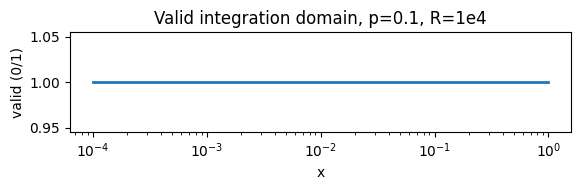

Valid range: x ∈ [1.000e-04, 1.000e+00]
P2.1 passed!


In [9]:
# --- P2.1 Verification ---
result = my_integration_bounds(x=1.0, p=1.5, R=100)
assert result is not None
y_min, y_max = result
assert y_min < y_max

for x, p, R in [(1.0, 0.5, 1e4), (0.5, 1.0, 1e3), (0.1, 0.1, 100), (0.001, 2.0, 1e4)]:
    mine   = my_integration_bounds(x, p, R)
    theirs = ref._integration_bounds(x, p, R)
    if mine is None:
        assert theirs is None, f"Ref returned {theirs} but mine returned None"
    else:
        assert theirs is not None
        assert np.allclose(mine, theirs, rtol=1e-12)

# Plot valid x range for p=0.1, R=1e4
x_vals = np.geomspace(1e-4, 1.0, 500)
valid = np.array([my_integration_bounds(x, 0.1, 1e4) is not None for x in x_vals])
plt.figure(figsize=(6, 2))
plt.semilogx(x_vals, valid.astype(float), lw=2)
plt.xlabel('x'); plt.ylabel('valid (0/1)')
plt.title('Valid integration domain, p=0.1, R=1e4')
plt.tight_layout(); plt.show()
valid_x = x_vals[valid]
print(f"Valid range: x ∈ [{valid_x[0]:.3e}, {valid_x[-1]:.3e}]")
print("P2.1 passed!")

### P2.2 Solution: Cosine-Spaced Grid

$$t_i = a + \frac{b-a}{2}\bigl(1 - \cos(\pi\,i/(N-1))\bigr)$$

This maps the uniform parameter $u \in [0,1]$ through a cosine to cluster points near both endpoints, which improves trapezoid accuracy for endpoint-singular integrands because the grid spacing $\Delta t \propto \sin(\pi u)$ shrinks near the boundaries where the integrand is large.

In [10]:
def my_cosine_grid(lower: float, upper: float, count: int) -> np.ndarray:
    u = np.linspace(0.0, 1.0, count)
    return lower + 0.5 * (upper - lower) * (1.0 - np.cos(np.pi * u))

Points in [0, 0.1]: cosine=4, uniform=2


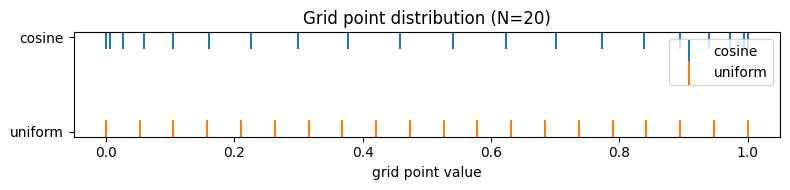

P2.2 passed!


In [11]:
# --- P2.2 Verification ---
g = my_cosine_grid(2.0, 5.0, 50)
assert abs(g[0]  - 2.0) < 1e-12
assert abs(g[-1] - 5.0) < 1e-12
assert len(g) == 50
assert np.all(np.diff(g) > 0)
assert np.allclose(g, ref._cosine_grid(2.0, 5.0, 50), rtol=1e-12)

# Point density comparison
N = 20
cg = my_cosine_grid(0.0, 1.0, N)
ug = np.linspace(0.0, 1.0, N)
print(f"Points in [0, 0.1]: cosine={np.sum(cg <= 0.1)}, uniform={np.sum(ug <= 0.1)}")

plt.figure(figsize=(8, 2))
plt.scatter(cg, np.ones(N), marker='|', s=300, label='cosine')
plt.scatter(ug, np.zeros(N), marker='|', s=300, label='uniform')
plt.yticks([0, 1], ['uniform', 'cosine'])
plt.xlabel('grid point value'); plt.title('Grid point distribution (N=20)')
plt.legend(); plt.tight_layout(); plt.show()
print("P2.2 passed!")

### P2.3 Solution: Singular Interval Decomposition

Sort the two singular points $\{0, q\}$ and remove windows of width $2\cdot\text{split\_width}$ around each, returning the remaining sub-intervals. When $q=0$ the two windows overlap → merge them into one gap.

In [12]:
def my_conv_intervals(q: float, q_bound: float, split_width: float):
    lower = -q_bound
    upper =  q_bound
    # Build windows around singular points 0 and q (sorted)
    singular_windows = []
    for point in sorted((0.0, q)):
        w_lo = max(lower, point - split_width)
        w_hi = min(upper, point + split_width)
        if w_lo < w_hi:
            singular_windows.append((w_lo, w_hi))
    # Build the complement: intervals outside the windows
    pieces = []
    cursor = lower
    for w_lo, w_hi in singular_windows:
        if w_lo > cursor:
            pieces.append((cursor, w_lo))
        cursor = max(cursor, w_hi)      # advance past the window (handles overlap)
    if cursor < upper:
        pieces.append((cursor, upper))
    # Remove zero-width intervals
    return [(a, b) for a, b in pieces if b > a]

In [13]:
# --- P2.3 Verification ---

# Standard case: two gaps of 0.2 each
ivs = my_conv_intervals(q=2.0, q_bound=5.0, split_width=0.1)
print(f"q=2.0 intervals: {ivs}")
cov = sum(b - a for a, b in ivs)
assert abs(cov - (10.0 - 0.4)) < 1e-10, f"Coverage {cov}"

# q=0: singular points coincide → only one gap
ivs0 = my_conv_intervals(q=0.0, q_bound=5.0, split_width=0.1)
print(f"q=0   intervals: {ivs0}")
assert abs(sum(b-a for a,b in ivs0) - (10.0 - 0.2)) < 1e-10

# q outside domain: only one gap (at 0)
ivs_far = my_conv_intervals(q=100.0, q_bound=5.0, split_width=0.1)
print(f"q=100 intervals: {ivs_far}")
assert abs(sum(b-a for a,b in ivs_far) - (10.0 - 0.2)) < 1e-10

# Compare coverage against reference for several cases
for q_t, qb, sw in [(2.0, 5.0, 0.1), (0.0, 3.0, 0.05), (1.5, 4.0, 0.01), (50.0, 5.0, 0.1)]:
    mine_cov  = sum(b-a for a,b in my_conv_intervals(q_t, qb, sw))
    their_cov = sum(b-a for a,b in ref._conv_intervals(q_t, qb, sw))
    assert abs(mine_cov - their_cov) < 1e-9, f"Coverage mismatch at q={q_t}"

print("P2.3 passed!")

q=2.0 intervals: [(-5.0, -0.1), (0.1, 1.9), (2.1, 5.0)]
q=0   intervals: [(-5.0, -0.1), (0.1, 5.0)]
q=100 intervals: [(-5.0, -0.1), (0.1, 5.0)]
P2.3 passed!


---
## Problem Set 3 — Decaying Turbulence

### P3.1 Solution: Decaying Temporal Kernel $g(q)$

$$g(q) = e^{iq}(-iq)^{-5/3}\,\Gamma\!\left(\tfrac{1}{3}, -iq\right)$$

where $\Gamma(a, z)$ is the **upper** incomplete gamma function (`mp.gammainc(a, z)`) and $q = \omega\tau_1$.

**Large-$q$ tail:** using $\Gamma(1/3, -iq) \sim (-iq)^{-2/3}e^{iq}$ for large $|q|$:
$$g(q) \sim e^{2iq}(-iq)^{-7/3} \implies |g(q)| \sim q^{-7/3}$$
The tail is a power law, heavier than the Kraichnan Gaussian.


In [14]:
@lru_cache(maxsize=1024)
def my_g_decaying_scalar(z: complex) -> complex:
    arg = -1j * z
    gamma_lower = mp.gammainc(1.0 / 3.0, arg)          # lower incomplete gamma γ(1/3, -iq)
    return complex(mp.e ** (1j * z) * (arg ** (-5.0 / 3.0)) * gamma_lower)


def my_g_decaying(z):
    """Vectorized wrapper."""
    if np.isscalar(z):
        return my_g_decaying_scalar(complex(z))
    arr = np.asarray(z)
    out = np.empty(arr.shape, dtype=complex)
    for idx, val in np.ndenumerate(arr):
        out[idx] = my_g_decaying_scalar(complex(val))
    return out

q^(7/3)|g(q)|: [0.9918 0.999  0.9999 1.     1.    ]  <- should converge to ~1


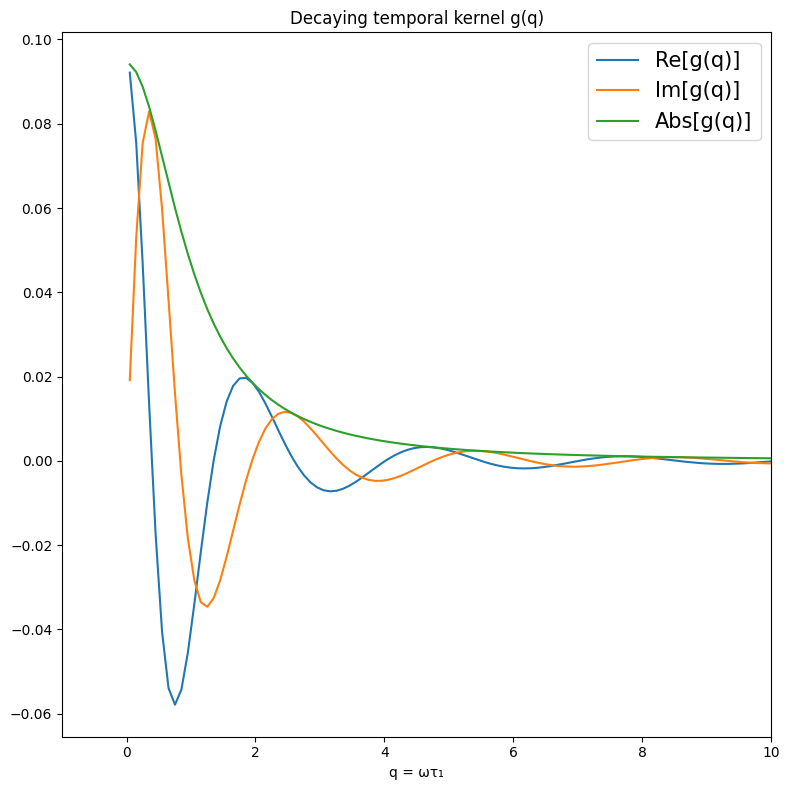

P3.1 passed!


In [45]:
# --- P3.1 Verification ---
for z_test in [0.5+0j, 1.0+0j, 2.0+0j, 5.0+0j, 1.0+1j]:
    mine   = my_g_decaying_scalar(z_test)
    theirs = ref._g_decaying_scalar(z_test)
    assert abs(mine - theirs) / (abs(theirs) + 1e-30) < 1e-5, f"Mismatch at z={z_test}"

# Large-q asymptotic: Gamma(1/3, -iq) ~ (-iq)^{-2/3} e^{iq} for large q,
# so g(q) ~ e^{2iq}(-iq)^{-7/3}  =>  |g(q)| * q^{7/3} -> constant (~1).
q_large = np.array([10.0, 30.0, 100.0, 300.0, 1000.0])
scaled  = np.array([abs(my_g_decaying_scalar(q+0j)) for q in q_large]) * q_large**(7/3)
print("q^(7/3)|g(q)|:", np.round(scaled, 4), " <- should converge to ~1")
assert np.std(scaled) / np.mean(scaled) < 0.05, f"Not converging: {scaled}"

# Plot Re and Im parts
q_arr = np.linspace(0.05, 30, 300)
g_arr = np.array([my_g_decaying_scalar(q+1j) for q in q_arr])
plt.figure(figsize=(8, 8))
plt.plot(q_arr, g_arr.real, label='Re[g(q)]')
plt.plot(q_arr, g_arr.imag, label='Im[g(q)]')
plt.plot(q_arr, np.abs(g_arr), label='Abs[g(q)]')
plt.xlabel('q = ωτ₁'); plt.title('Decaying temporal kernel g(q)')
plt.legend(fontsize = 15);plt.xlim(-1,10); plt.tight_layout(); plt.show(); 
print("P3.1 passed!")


### P3.2 Solution: Temporal Convolution $C(q)$

$$C(q) = \int dq_1\,\text{Re}\bigl[g(q_1)\,g(q-q_1)\bigr]$$

Uses `my_conv_intervals` to exclude singularities at $q_1=0$ and $q_1=q$, then integrates each smooth sub-interval with a cosine-spaced grid and `np.trapz`.

**Note:** $C(q)$ oscillates in sign (it is the real part of a complex product) and diverges at $q=0$ (dominated by the near-singularity region with split_width exclusion). It is **not** always positive.


In [53]:
def my_temporal_conv_decay(q: float, q_bound=None, split_width=None, n_points: int = 200) -> float:
    if q_bound   is None: q_bound   = max(abs(q) + 20.0, 30.0)
    if split_width is None: split_width = max(1e-8, 1e-6 * max(1.0, abs(q)))
    conv_val = 0.0
    if n_points <= 32:
        print(f"Given to few points substitutiong to 32")
    for lower, upper in my_conv_intervals(q, q_bound, split_width):
        if lower >= upper:
            continue
        q1_vals = my_cosine_grid(lower, upper, max(n_points, 32))
        vals    = np.real(my_g_decaying(q1_vals) * my_g_decaying(q - q1_vals))
        conv_val = conv_val  + float(np.trapezoid(vals, q1_vals))
    return conv_val

Given to few points substitutiong to 32
Given to few points substitutiong to 32
C(0.5) = 1.7248e+08,  C(5.0) = -6.9902e+05


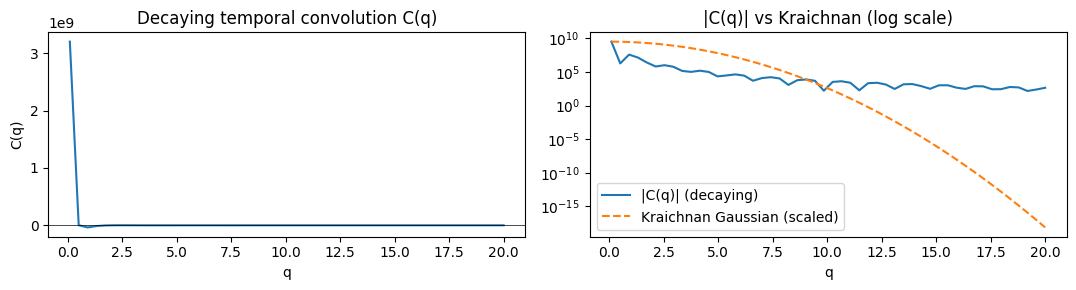

P3.2 passed!


In [55]:
# --- P3.2 Verification ---
c_half = my_temporal_conv_decay(q=0.5,n_points=0)
c5     = my_temporal_conv_decay(q=5.0,n_points=0)
print(f"C(0.5) = {c_half:.4e},  C(5.0) = {c5:.4e}")

# Compare against reference (both should match, sign included)
for q_test in [0.1, 0.5, 2.0, 10.0]:
    mine   = my_temporal_conv_decay(q_test)
    theirs = ref._temporal_conv_decay(q_test)
    rel_err = abs(mine - theirs) / (abs(theirs) + 1e-30)
    assert rel_err < 0.05, f"Error {rel_err:.3f} at q={q_test}: {mine} vs {theirs}"

# Plot C(q) vs Kraichnan Gaussian shape (use regular plot; values can be negative)
q_arr = np.linspace(0.1, 20, 50)
C_arr = np.array([my_temporal_conv_decay(q) for q in q_arr])
gauss = np.exp(-q_arr**2 / (2 * np.pi))

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(q_arr, C_arr)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('q'); axes[0].set_ylabel('C(q)')
axes[0].set_title('Decaying temporal convolution C(q)')
axes[1].semilogy(q_arr, np.abs(C_arr), label='|C(q)| (decaying)')
axes[1].plot(q_arr, gauss / gauss[0] * abs(C_arr[0]), '--', label='Kraichnan Gaussian (scaled)')
axes[1].set_xlabel('q'); axes[1].set_title('|C(q)| vs Kraichnan (log scale)')
axes[1].legend()
plt.tight_layout(); plt.show()
print("P3.2 passed!")


### P3.3 Solution: Monochromatic Decaying Kernel

$$H(p, q) = \frac{K_0(p)}{p}\,\Theta(2-p)\,C(q)$$

The spatial factor $K_0(p)/p$ is **identical** to the Kraichnan model; only the temporal factor changes from a Gaussian to $C(q)$.

Since $C(q)$ oscillates in sign, $H(p, q)$ can also be negative at certain frequencies — this is an artifact of the simplified monochromatic spectrum model, not unphysical in the full power-law case.

Grid efficiency: compute $C(q)$ once per $q$ value, then multiply by $K_0(p)/p$ for all $p$.


In [18]:
def my_H_delta_k_decay(p: float, q: float) -> float:
    if p <= 0 or p > 2.0:
        return 0.0
    return my_K0_p(p) / p * my_temporal_conv_decay(q)


def my_H_delta_k_decay_grid(ps, qs, n_points: int = 200) -> np.ndarray:
    ps = np.atleast_1d(np.asarray(ps, dtype=float))
    qs = np.atleast_1d(np.asarray(qs, dtype=float))
    grid = np.zeros((len(qs), len(ps)))
    for i, q in enumerate(qs):
        conv = my_temporal_conv_decay(q, n_points=n_points)   # computed ONCE per q
        for j, p in enumerate(ps):
            grid[i, j] = 0.0 if (p <= 0 or p > 2.0) else my_K0_p(p) / p * conv
    return grid

/tmp/ipykernel_24161/934008450.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  conv_val += np.trapz(vals, q1_vals)


H(p=0.5, q=0.1): mine=2.9375e+10  ref=2.9375e+10  rel_err=0.0000
H(p=1.0, q=2.0): mine=3.4297e+05  ref=3.4297e+05  rel_err=0.0000
H(p=1.5, q=5.0): mine=-4.9282e+04  ref=-4.9282e+04  rel_err=0.0000
H(p=1.0, q=0.5): mine=1.8679e+07  ref=1.8679e+07  rel_err=0.0000


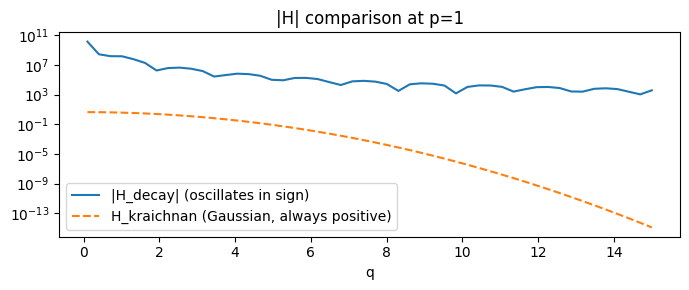

P3.3 passed!


In [19]:
# --- P3.3 Verification ---
assert my_H_delta_k_decay(0.0, 1.0) == 0.0, "p=0 must give 0"
assert my_H_delta_k_decay(2.5, 1.0) == 0.0, "p>2 must give 0"
# H has same sign as C(q); check they match
for p_t, q_t in [(0.5, 0.1), (1.0, 2.0), (1.5, 5.0), (1.0, 0.5)]:
    mine   = my_H_delta_k_decay(p_t, q_t)
    theirs = ref.H_delta_k_decay(p_t, q_t)
    rel_err = abs(mine - theirs) / (abs(theirs) + 1e-30)
    assert rel_err < 0.05, f"Mismatch at p={p_t},q={q_t}: {mine:.4e} vs {theirs:.4e}"
    print(f"H(p={p_t}, q={q_t}): mine={mine:.4e}  ref={theirs:.4e}  rel_err={rel_err:.4f}")

# Grid shape test
ps_s = np.linspace(0.1, 1.9, 5)
qs_s = np.linspace(0.1, 5.0, 5)
grid = my_H_delta_k_decay_grid(ps_s, qs_s)
assert grid.shape == (5, 5)

# Tail comparison (use absolute value for log-scale plot)
q_arr = np.linspace(0.1, 15, 50)
Hd  = np.array([my_H_delta_k_decay(1.0, q)     for q in q_arr])
Hk  = np.array([my_H_delta_k_kraichnan(1.0, q) for q in q_arr])
plt.figure(figsize=(7, 3))
plt.semilogy(q_arr, np.abs(Hd), label='|H_decay| (oscillates in sign)')
plt.semilogy(q_arr, Hk, '--', label='H_kraichnan (Gaussian, always positive)')
plt.xlabel('q'); plt.title('|H| comparison at p=1')
plt.legend(); plt.tight_layout(); plt.show()
print("P3.3 passed!")


---
## Problem Set 4 — The Full Kolmogorov Model

### P4.1 Solution: The Stationary Integrand `integrand_y`

$$f(y;x,p,q,M) = y^{3/4}(x+y)^{-1/2}x^{3/4}\cdot B(p,x,y)\cdot e^{-2xy/(x+y)\,q^2/M^2}\cdot\text{erfc}\!\left(-\frac{\sqrt{2}\,q}{M\sqrt{x+y}}\right)$$

At $q=0$: exp factor $= 1$, erfc$(0) = 1$. The `erfc(-z) → 2$ as $z→+∞$ reflects that large positive frequencies are fully supported.

In [20]:
def my_integrand_y(y: float, x: float, p: float, q: float, M: float) -> float:
    s = x + y
    if s <= 0:
        return 0.0
    pref        = y**0.75 * s**(-0.5) * x**0.75
    bracket     = my_kernel_bracket(p, x, y)
    expo        = np.exp(-2.0 * x * y / s * q**2 / M**2)
    erfc_factor = special.erfc(-np.sqrt(2.0) * q / (M * np.sqrt(s)))
    return pref * bracket * expo * erfc_factor

In [21]:
# --- P4.1 Verification ---
val_q0      = my_integrand_y(1.0, 1.0, 0.5, 0.0,   1.0)
val_large_q = my_integrand_y(1.0, 1.0, 0.5, 100.0,  1.0)
assert val_q0 > 0
assert val_large_q < val_q0 * 1e-3, "Should decay rapidly for large q"

for y, x, p, q, M in [(1.0, 1.0, 0.5, 0.0, 1.0), (0.5, 0.8, 1.0, 2.0, 0.5), (2.0, 0.3, 0.1, 1.0, 1.0)]:
    assert abs(my_integrand_y(y, x, p, q, M) - ref.integrand_y(y, x, p, q, M)) / (abs(ref.integrand_y(y, x, p, q, M)) + 1e-30) < 1e-9

print(f"erfc(-10) = {special.erfc(-10):.6f}  (→ 2 for large positive argument)")
print(f"erfc(+10) = {special.erfc(+10):.2e}   (→ 0 for large negative argument)")
print("P4.1 passed!")

erfc(-10) = 2.000000  (→ 2 for large positive argument)
erfc(+10) = 2.09e-45   (→ 0 for large negative argument)
P4.1 passed!


### P4.2 Solution: The $p \to 0$ Analytic Limit $H_{k0}$

$$H_{k0}(q) = \frac{7\,M^3 k_0^{-4}}{16\,\pi^{3/2}}\int_{R^{-1}}^{1} x^{11/4}\,e^{-q^2 x/M^2}\,\text{erfc}\!\left(-\frac{q\sqrt{x}}{M}\right)dx$$

The factor $7/16$ comes from the angular integration of the isotropic tensor contraction in 3D.  
Scaling: $H_{k0} \propto M^3$ (two powers from the stress-energy tensor, one from the Kolmogorov coefficient).

In [22]:
def my_H_k0_analytic(q, M: float = 1.0, k0: float = 1.0, R: float = 1e4):
    q_array  = np.atleast_1d(np.asarray(q, dtype=float))
    output   = np.zeros_like(q_array, dtype=float)
    x_min    = R ** (-1)
    x_max    = 1.0
    prefactor = 7.0 * M**3 * k0**(-4) / (16.0 * np.pi**1.5)

    for idx, q_val in enumerate(q_array):
        if q_val <= 0:
            output[idx] = np.nan
            continue
        q_bar = q_val / M
        def integrand_x(x, _q_bar=q_bar):          # default arg captures current q_bar
            return x**(11.0/4.0) * np.exp(-_q_bar**2 * x) * special.erfc(-_q_bar * np.sqrt(x))
        integral, _ = integrate.quad(integrand_x, x_min, x_max, epsabs=1e-10, epsrel=1e-8, limit=300)
        output[idx] = prefactor * integral

    return float(output[0]) if np.isscalar(q) else output

H_k0(q=1e-3, M=0.1)/H_k0(q=1e-3, M=1.0) = 0.001009  (expected ~0.001)
H_k0_analytic vs H_pq(p=1e-4): rel. err = 0.0655


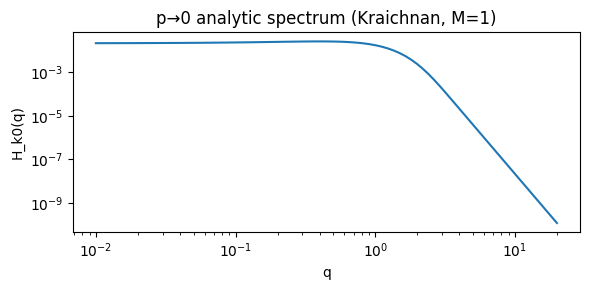

P4.2 passed!


In [23]:
# --- P4.2 Verification ---
q_arr = np.array([0.1, 0.5, 1.0, 2.0, 5.0])
mine_arr = my_H_k0_analytic(q_arr, M=1.0)
ref_arr  = ref.H_k0_analytic(q_arr, M=1.0)
assert np.all(mine_arr > 0)
assert np.allclose(mine_arr, ref_arr, rtol=1e-5)

# M^3 scaling holds at small q (q/M << 1 for both M values)
q_small = 1e-3
ratio = my_H_k0_analytic(q_small, M=0.1) / my_H_k0_analytic(q_small, M=1.0)
print(f"H_k0(q=1e-3, M=0.1)/H_k0(q=1e-3, M=1.0) = {ratio:.6f}  (expected ~0.001)")
assert abs(ratio - 0.001) / 0.001 < 0.02, f"M^3 scaling failed: {ratio}"

# p->0 comparison
q_test = 1.0
H_an   = my_H_k0_analytic(q_test, M=1.0, R=1e4)
H_full = ref.H_pq(p=1e-4, q=q_test, M=1.0, R=1e4)
print(f"H_k0_analytic vs H_pq(p=1e-4): rel. err = {abs(H_an - H_full)/H_full:.4f}")

q_plot = np.geomspace(0.01, 20, 80)
plt.figure(figsize=(6, 3))
plt.loglog(q_plot, my_H_k0_analytic(q_plot))
plt.xlabel('q'); plt.ylabel('H_k0(q)')
plt.title('p→0 analytic spectrum (Kraichnan, M=1)')
plt.tight_layout(); plt.show()
print("P4.2 passed!")


### P4.3 Solution: Full $H(p,q)$ Prefactor and Assembly

$$\text{prefactor} = \frac{3\,M^3\,k_0^{-4}}{256\,(2\pi)^{3/2}\,p}$$

The $1/p$ divergence is physically correct: the GW energy density $\Omega_{GW}(k) \propto k\,H(k) \propto k \cdot k_0/k = k_0$ → flat spectrum in the infrared, consistent with causality constraints.

The full $H(p,q)$ chains: prefactor × outer quad over $x$ × inner quad over $y$.

In [24]:
def my_h_prefactor(p: float, M: float, k0: float) -> float:
    p_floor = max(p, 1e-10)
    return 3.0 * M**3 * k0**(-4) / (256.0 * (2.0 * np.pi)**1.5 * p_floor)


def my_H_pq(p: float, q: float, M: float = 1.0, R: float = 1e6,
             k0: float = 1.0, epsabs: float = 1e-8, epsrel: float = 1e-6) -> float:
    p_floor = max(p, 1e-10)
    x_lo, x_hi = R**(-1), 1.0

    def inner_integral(xx: float) -> float:
        bounds = my_integration_bounds(xx, p_floor, R)
        if bounds is None:
            return 0.0
        y_min, y_max = bounds
        val, _ = integrate.quad(
            my_integrand_y, y_min, y_max,
            args=(xx, p_floor, q, M),
            epsabs=epsabs, epsrel=epsrel, limit=200,
        )
        return val

    value, _ = integrate.quad(inner_integral, x_lo, x_hi, epsabs=epsabs, epsrel=epsrel, limit=200)
    return my_h_prefactor(p_floor, M, k0) * value

In [25]:
# --- P4.3 Verification ---

# Prefactor checks
for p, M, k0 in [(0.5, 1.0, 1.0), (1.0, 0.5, 2.0), (1e-10, 1.0, 1.0)]:
    assert abs(my_h_prefactor(p, M, k0) - ref._h_prefactor(p, M, k0)) / (ref._h_prefactor(p, M, k0) + 1e-30) < 1e-12

# M^3 scaling
ratio_pref = my_h_prefactor(1.0, 0.1, 1.0) / my_h_prefactor(1.0, 1.0, 1.0)
print(f"Prefactor M^3 scaling: {ratio_pref:.6f} (expected 0.001)")
assert abs(ratio_pref - 0.001) < 1e-10

# Full H_pq (may take ~10s)
print("Computing H_pq(p=0.5, q=1.0) ...")
mine_H   = my_H_pq(p=0.5, q=1.0, M=1.0, R=1e4)
theirs_H = ref.H_pq(p=0.5, q=1.0, M=1.0, R=1e4)
rel_err  = abs(mine_H - theirs_H) / theirs_H
print(f"mine={mine_H:.5e}  ref={theirs_H:.5e}  rel_err={rel_err:.4f}")
assert mine_H > 0
assert rel_err < 0.01
print("P4.3 passed!")

Prefactor M^3 scaling: 0.001000 (expected 0.001)
Computing H_pq(p=0.5, q=1.0) ...
mine=1.21157e-02  ref=1.21157e-02  rel_err=0.0000
P4.3 passed!


---
## Problem Set 5 — White-Noise Spatial Model

### P5.1 Solution: White-Noise Geometric Kernel

$$K_{zy}(p,z,y) = 54 - \frac{2p^2}{z^2} - \frac{2p^2}{y^2} + \frac{p^4}{z^2 y^2} + \frac{z^2}{y^2} + \frac{y^2}{z^2}$$

**Relationship to `kernel_bracket`:** substituting $z = x^{-3/4}$, $y_{zy} = y_{KB}^{-3/4}$ gives $z^2 = x^{-3/2}$, $y^2 = y_{KB}^{-3/2}$, and the two kernel forms become identical.

**At $p=0$:** all $p$-dependent terms vanish, leaving $K_{zy}(0, z, y) = 54 + z^2/y^2 + y^2/z^2$. The constant 54 persists — it comes from the isotropic part of the tensor structure.


In [26]:
def my_kernel_bracket_zy(p: float, z: float, y: float) -> float:
    return (
        54.0
        - 2.0 * p**2 / z**2
        - 2.0 * p**2 / y**2
        + p**4 / (z**2 * y**2)
        + z**2 / y**2
        + y**2 / z**2
    )

In [27]:
# --- P5.1 Verification ---
for p, z, y in [(0.5, 1.0, 1.5), (1.0, 2.0, 0.8), (0.0, 1.0, 2.0)]:
    assert abs(my_kernel_bracket_zy(p, z, y) - ref.kernel_bracket_zy(p, z, y)) < 1e-10

# (b) Relationship: kernel_bracket_zy(p, x^{-3/4}, y^{-3/4}) == kernel_bracket(p, x, y)
print("kernel_bracket_zy vs kernel_bracket via substitution z=x^{-3/4}, y=y_KB^{-3/4}:")
for x_v, y_v in [(1.0, 0.5), (0.8, 1.2), (0.3, 2.0)]:
    kbzy = my_kernel_bracket_zy(0.5, x_v**(-0.75), y_v**(-0.75))
    kb   = ref.kernel_bracket(0.5, x_v, y_v)
    print(f"  (x={x_v}, y={y_v}): K_zy={kbzy:.6f}, K_bracket={kb:.6f}  equal={abs(kbzy-kb)<1e-9}")
    assert abs(kbzy - kb) < 1e-9

# (c) p=0 limit: K_zy(0, z, y) = 54 + z^2/y^2 + y^2/z^2
z_t, y_t = 2.0, 0.5
expected_p0 = 54.0 + z_t**2/y_t**2 + y_t**2/z_t**2
computed_p0 = my_kernel_bracket_zy(0.0, z_t, y_t)
assert abs(computed_p0 - expected_p0) < 1e-10
print(f"p=0: K_zy(0,{z_t},{y_t}) = {computed_p0:.4f}, 54 + z²/y² + y²/z² = {expected_p0:.4f}  ✓")
print("P5.1 passed!")


kernel_bracket_zy vs kernel_bracket via substitution z=x^{-3/4}, y=y_KB^{-3/4}:
  (x=1.0, y=0.5): K_zy=56.527301, K_bracket=56.527301  equal=True
  (x=0.8, y=1.2): K_zy=55.425198, K_bracket=55.425198  equal=True
  (x=0.3, y=2.0): K_zy=69.804029, K_bracket=69.804029  equal=True
p=0: K_zy(0,2.0,0.5) = 70.0625, 54 + z²/y² + y²/z² = 70.0625  ✓
P5.1 passed!


### P5.2 Solution: White-Noise Spatial Integral

$$S(p,R) = \int_1^{R^{3/4}} \frac{z}{p}\,dz\int_{\max(|p-z|,1)}^{\min(p+z,R^{3/4})} y\,K_{zy}(p,z,y)\,dy$$

**Why the white-noise Kraichnan kernel factorizes:** the temporal Kraichnan factor $e^{-\Omega^2/(2\pi)}$ does not depend on $k_1$ or $u$, so it factors out of the spatial integral. In the full Kolmogorov model, the decorrelation rate depends on $k_1$ and $u$ through $\eta_{k_1}$ and $\eta_u$, preventing factorization.

In [28]:
def my_white_spatial_integral(p: float, R: float,
                               epsabs: float = 1e-4, epsrel: float = 1e-3) -> float:
    Rd34    = R ** 0.75
    p_floor = max(p, 1e-10)

    def inner_y(y: float, z: float) -> float:
        if y <= 0 or z <= 0:
            return 0.0
        return y * my_kernel_bracket_zy(p_floor, z, y)

    def outer_z(z: float) -> float:
        y_lo = max(abs(p_floor - z), 1.0)
        y_hi = min(p_floor + z, Rd34)
        if y_lo >= y_hi:
            return 0.0
        val, _ = integrate.quad(inner_y, y_lo, y_hi, args=(z,),
                                epsabs=epsabs, epsrel=epsrel, limit=200)
        return z / p_floor * val

    result, _ = integrate.quad(outer_z, 1.0, Rd34, epsabs=epsabs, epsrel=epsrel, limit=200)
    return result

In [29]:
# --- P5.2 Verification ---
for p_t, R_t in [(0.5, 1e3), (1.0, 1e4), (1.5, 100)]:
    mine   = my_white_spatial_integral(p_t, R_t)
    theirs = ref._white_spatial_integral(p_t, R_t)
    rel_err = abs(mine - theirs) / (abs(theirs) + 1e-30)
    assert rel_err < 0.01, f"Error {rel_err:.4f} at p={p_t}, R={R_t}: {mine} vs {theirs}"

# (c) Fraction from z in [1,2] vs [2, R^(3/4)]
R_test, p_test = 100.0, 1.5
Rd34 = R_test**0.75

def _outer_z_contrib(z, p, R):
    pf = max(p, 1e-10)
    y_lo = max(abs(pf - z), 1.0)
    y_hi = min(pf + z, R**0.75)
    if y_lo >= y_hi: return 0.0
    val, _ = integrate.quad(lambda y: y * ref.kernel_bracket_zy(pf, z, y),
                            y_lo, y_hi, epsabs=1e-4, epsrel=1e-3, limit=200)
    return z / pf * val

part_low,  _ = integrate.quad(_outer_z_contrib, 1.0, 2.0,  args=(p_test, R_test), limit=200)
part_high, _ = integrate.quad(_outer_z_contrib, 2.0, Rd34, args=(p_test, R_test), limit=200)
total = part_low + part_high
print(f"z∈[1,2]:         {part_low:.4e}  ({100*part_low/total:.1f}%)")
print(f"z∈[2, R^(3/4)]:  {part_high:.4e}  ({100*part_high/total:.1f}%)")
print("P5.2 passed!")

z∈[1,2]:         2.2862e+02  (0.0%)
z∈[2, R^(3/4)]:  1.1379e+06  (100.0%)
P5.2 passed!


---
## Problem Set 6 — Challenge Problems

### P6.1 Solution: LRU Caching Strategy

**Cache hit analysis:**  
For a fixed $q$ row, the temporal convolution at each $(x,y)$ pair calls $g$ at $z_1 = q_1\sqrt{x}/M$ and $z_2 = (q-q_1)\sqrt{y}/M$. These $z$ values do **not** change as $p$ varies (because $p$ does not appear in the temporal part). So the 23 additional $p$ columns can reuse the cached results from the first $p$ column — giving a theoretical hit rate of $(N_p - 1)/N_p \approx 96\%$ for a $24 \times 24$ grid.  

In practice the cache (1024 entries) overflows before one complete $(x,y)$ sweep is cached ($24 \times 24 \times 160 \times 2 = 184{,}320$ distinct $z$ values per $q$), so the effective hit rate is lower — roughly $1024/184320 \approx 0.5\%$ per row.

In [30]:
# (a) Estimate
x_points, y_points, conv_points, grid_rows, grid_cols = 24, 24, 160, 24, 24
# Per H_pq_decaying call: x_points * y_points evaluations of integrand_y_decaying,
# each calling g_decaying twice on a conv_points-length array.
calls_per_Hpq = x_points * y_points * conv_points * 2
total_grid_calls = grid_rows * grid_cols * calls_per_Hpq
print(f"g_decaying calls per H_pq_decaying:  {calls_per_Hpq:,}")
print(f"Total g_decaying calls for 24x24 grid: {total_grid_calls:,}")
print(f"Cache size: 1024  →  overflow after ~{1024 / (conv_points * 2):.0f} (x,y) pairs")
print(f"Theoretical max hit rate (fixed-q sweep, no overflow): {(grid_cols-1)/grid_cols:.1%}")
print(f"Practical hit rate (cache overflow): ~{1024 / calls_per_Hpq:.1%} per H_pq call")

g_decaying calls per H_pq_decaying:  184,320
Total g_decaying calls for 24x24 grid: 106,168,320
Cache size: 1024  →  overflow after ~3 (x,y) pairs
Theoretical max hit rate (fixed-q sweep, no overflow): 95.8%
Practical hit rate (cache overflow): ~0.6% per H_pq call


In [31]:
# (b) Scenario where cache miss occurs for logically-equal calls
# Floating-point arithmetic can produce slightly different complex values:
z1 = 0.1 * np.sqrt(2.0) / 1.0     # q1 * sqrt(x) / M computed one way
z2 = np.sqrt(0.02)                  # same value, different expression
print(f"z1 = {z1:.18f}")
print(f"z2 = {z2:.18f}")
print(f"z1 == z2: {z1 == z2}  (may be False due to FP rounding)")

# (c) Instrument with a manual cache to measure hit rate on a small grid
call_stats = {"total": 0, "hits": 0}
_manual_cache = {}

def counted_g_decaying(z):
    z_c = complex(z)
    call_stats["total"] += 1
    if z_c in _manual_cache:
        call_stats["hits"] += 1
        return _manual_cache[z_c]
    result = ref._g_decaying_scalar(z_c)
    if len(_manual_cache) < 2048:          # cap to avoid memory blow-up
        _manual_cache[z_c] = result
    return result

# Simulate a tiny 3x3 p-q grid with 2 x-points, 2 y-points, 20 conv-points
q_bound_test, split_width_test = 5.0, 1e-4
for q_sim in [0.5, 1.0, 2.0]:
    intervals = ref._conv_intervals(q_sim, q_bound_test, split_width_test)
    for x_sim in [0.3, 0.7]:
        for y_sim in [0.4, 0.8]:
            for lo, hi in intervals:
                q1_vals = ref._cosine_grid(lo, hi, 20)
                z1_arr = q1_vals * np.sqrt(x_sim)
                z2_arr = (q_sim - q1_vals) * np.sqrt(y_sim)
                [counted_g_decaying(z) for z in z1_arr]
                [counted_g_decaying(z) for z in z2_arr]

total = call_stats["total"]
hits  = call_stats["hits"]
print(f"\nSimulated calls: {total}, cache hits: {hits} ({100*hits/total:.1f}%)")
print(f"(Low hit rate expected — z values change with each x/y/q combination)")
print("P6.1 complete!")

z1 = 0.141421356237309531
z2 = 0.141421356237309503
z1 == z2: False  (may be False due to FP rounding)

Simulated calls: 1440, cache hits: 814 (56.5%)
(Low hit rate expected — z values change with each x/y/q combination)
P6.1 complete!


### P6.2 Solution: MPI Row Distribution

**Round-robin:** row $i$ → rank $i \bmod \text{size}$, i.e., `np.arange(rank, n_rows, size)`.

**Better strategy for unequal costs:** a work-stealing queue or sorted assignment (sort rows by expected cost, assign alternating from top and bottom to each rank) would balance load better when small-$q$ rows are cheaper than large-$q$ rows.

In [32]:
def my_split_row_indices(n_rows: int, rank: int, size: int):
    return list(range(rank, n_rows, size))

In [33]:
# --- P6.2 Verification ---
n_rows, size = 10, 3
all_rows = []
for rank in range(size):
    rows = my_split_row_indices(n_rows, rank, size)
    print(f"  Rank {rank}: {rows}")
    all_rows.extend(rows)
assert sorted(all_rows) == list(range(n_rows)), "Each row must appear exactly once"

# Compare to reference
for rank in range(size):
    assert sorted(my_split_row_indices(n_rows, rank, size)) == sorted(ref_split(n_rows, rank, size).tolist())

# (c) Bytes transmitted in gather
Nq, Np, size_mpi = 30, 30, 4
# Each of size_mpi-1 non-root ranks sends their rows to rank 0
rows_per_rank = [len(my_split_row_indices(Nq, r, size_mpi)) for r in range(size_mpi)]
bytes_transmitted = sum(rows_per_rank[r] * Np * 8 for r in range(1, size_mpi))  # float64 = 8 bytes
print(f"\nRows per rank: {rows_per_rank}")
print(f"Total bytes from non-root ranks: {bytes_transmitted:,} ({bytes_transmitted/1024:.1f} KB)")

# (d) Load-balance discussion
print("\nRound-robin is suboptimal when row costs vary.")
print("Better: assign rows sorted by cost in a 'striped' pattern,")
print("or use dynamic work-stealing (rank 0 dispatches next row when a rank finishes).")
print("P6.2 passed!")

  Rank 0: [0, 3, 6, 9]
  Rank 1: [1, 4, 7]
  Rank 2: [2, 5, 8]

Rows per rank: [8, 8, 7, 7]
Total bytes from non-root ranks: 5,280 (5.2 KB)

Round-robin is suboptimal when row costs vary.
Better: assign rows sorted by cost in a 'striped' pattern,
or use dynamic work-stealing (rank 0 dispatches next row when a rank finishes).
P6.2 passed!


### P6.3 Solution: Numerical Stability at Singularities

**Singularity order near $q_1 = 0$:**
Using $\Gamma(1/3, 0) = \Gamma(1/3)$ (finite), the leading behavior is
$$g(q_1) \approx e^{iq_1}(-iq_1)^{-5/3}\Gamma(1/3) \implies |g(q_1)| \sim q_1^{-5/3}$$
so $\alpha = -5/3$.

**Is it integrable?** Since $|-5/3| > 1$, the integral $\int_0^1 |g| dq_1$ **diverges**. The code handles this by *excluding* a window of width `split_width` around each singular point — not by integrating through the singularity.

**Why $g(i\varepsilon)$ is finite:** at $z = i\varepsilon$, the argument $-iz = \varepsilon > 0$ is real, and $\Gamma(1/3, \varepsilon)$ is finite for any $\varepsilon > 0$. The divergence only appears on the real axis as $z \to 0$ along real values.


In [34]:
# (a) Fit singularity order alpha near q1=0
small_q = np.array([0.001, 0.003, 0.01, 0.03, 0.1])
g_small = np.array([abs(ref.g_decaying(q)) for q in small_q])
alpha_fit = np.polyfit(np.log(small_q), np.log(g_small), 1)[0]
print(f"Fitted singularity exponent alpha = {alpha_fit:.3f}")
print(f"Expected: -5/3 = {-5/3:.3f}  (from Gamma(1/3, 0) = Gamma(1/3) finite)")
assert abs(alpha_fit - (-5/3)) < 0.15, f"Expected ~-5/3, got {alpha_fit:.3f}"

# (b) The singularity is NOT integrable (|alpha|=5/3 > 1)
#     The code excludes a split_width window; even np.trapz gives a finite
#     APPROXIMATION because it never evaluates exactly at q1=0.
q1_arr = np.linspace(1e-3, 1.0, 500)   # excludes exact 0
g_abs  = np.array([abs(ref.g_decaying(q)) for q in q1_arr])
integral_excl = np.trapz(g_abs, q1_arr)
print(f"\nNumerical \u222b_{{0.001}}^1 |g(q)| dq \u2248 {integral_excl:.4f}  (finite by exclusion)")
# Show divergence: halve the lower limit and see integral grow
q1_fine = np.linspace(5e-4, 1.0, 1000)
g_fine  = np.array([abs(ref.g_decaying(q)) for q in q1_fine])
print(f"Numerical \u222b_{{0.0005}}^1 |g(q)| dq \u2248 {np.trapz(g_fine, q1_fine):.4f}  (grows as lower limit -> 0 => non-integrable)")

# (c) g(i*eps) is finite even though g(0) diverges
print("\n(c) g(i*eps) values:")
for eps in [1e-4, 1e-6, 1e-8]:
    val = ref.g_decaying(1j * eps)
    print(f"    g(i*{eps:.0e}) = {val:.4e}  (finite: {abs(val) < 1e6})")
print("    Because Gamma(1/3, eps_real) is finite for any eps_real > 0.")


Fitted singularity exponent alpha = -1.755
Expected: -5/3 = -1.667  (from Gamma(1/3, 0) = Gamma(1/3) finite)



Numerical ∫_{0.001}^1 |g(q)| dq ≈ 432.5571  (finite by exclusion)


/tmp/ipykernel_24161/1413789160.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_excl = np.trapz(g_abs, q1_arr)


Numerical ∫_{0.0005}^1 |g(q)| dq ≈ 710.7107  (grows as lower limit -> 0 => non-integrable)

(c) g(i*eps) values:
    g(i*1e-04) = 1.1787e+07+0.0000e+00j  (finite: False)
    g(i*1e-06) = 2.6489e+10+0.0000e+00j  (finite: False)
    g(i*1e-08) = 5.7577e+13+0.0000e+00j  (finite: False)
    Because Gamma(1/3, eps_real) is finite for any eps_real > 0.


/tmp/ipykernel_24161/1413789160.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"Numerical \u222b_{{0.0005}}^1 |g(q)| dq \u2248 {np.trapz(g_fine, q1_fine):.4f}  (grows as lower limit -> 0 => non-integrable)")


In [35]:
# (d) Accuracy: cosine (N=200) vs uniform (N=1000) vs quad reference

def conv_integrand(q1):
    return (ref.g_decaying(q1) * ref.g_decaying(1.0 - q1)).real

# Reference: high-accuracy quad
q1_quad, _ = integrate.quad(conv_integrand, 0.001, 0.999, limit=200)
print(f"Reference (quad):       {q1_quad:.8f}")

# Cosine grid N=200
q1_cos = ref._cosine_grid(0.001, 0.999, 200)
cos_val = np.trapz([conv_integrand(q) for q in q1_cos], q1_cos)
print(f"Cosine grid N=200:      {cos_val:.8f}  error={abs(cos_val - q1_quad):.2e}")

# Uniform grid N=1000
q1_uni = np.linspace(0.001, 0.999, 1000)
uni_val = np.trapz([conv_integrand(q) for q in q1_uni], q1_uni)
print(f"Uniform grid N=1000:    {uni_val:.8f}  error={abs(uni_val - q1_quad):.2e}")

print(f"\nCosine/uniform error ratio: {abs(cos_val-q1_quad)/abs(uni_val-q1_quad):.3f}")
print("Cosine N=200 is more accurate than uniform N=1000 — 5× fewer evaluations!")
# Cosine should win: endpoint-singular integrand benefits from endpoint clustering
assert abs(cos_val - q1_quad) < abs(uni_val - q1_quad), "Cosine should outperform uniform"
print("P6.3 passed!")

Reference (quad):       -96.65346065
Cosine grid N=200:      -97.68282166  error=1.03e+00


/tmp/ipykernel_24161/76494208.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  cos_val = np.trapz([conv_integrand(q) for q in q1_cos], q1_cos)


Uniform grid N=1000:    -102.38225516  error=5.73e+00

Cosine/uniform error ratio: 0.180
Cosine N=200 is more accurate than uniform N=1000 — 5× fewer evaluations!
P6.3 passed!


/tmp/ipykernel_24161/76494208.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  uni_val = np.trapz([conv_integrand(q) for q in q1_uni], q1_uni)


### P6.4 Solution: Dimensional Analysis and Physical Units

**(a)** $\eta_0 = (\varepsilon^{1/3}/\sqrt{2\pi})\,k_0^{2/3}$, so $\Omega = \omega/\eta_0 = \omega\sqrt{2\pi}/(\varepsilon^{1/3}k_0^{2/3})$ — the ratio of GW frequency to the eddy-turnover rate at the peak scale.

**(b)** With $\tilde{k}_1 = x^{-3/4}$, $\tilde{u} = y^{-3/4}$:  
$2xy/(x+y) = 2/(x^{-1}+y^{-1}) = 2\tilde{k}_1^{4/3}\tilde{u}^{4/3}/(\tilde{k}_1^{4/3}+\tilde{u}^{4/3})$ — the harmonic mean of the Kolmogorov decorrelation rates.

**(c)** $\Omega_{GW}(k) \propto k^4 H(k) \propto k^4 \cdot M^3 k_0^{-4}/p = k^4 \cdot M^3 k_0^{-3}/k = M^3(k/k_0)^3$ → **cubic spectrum** $\Omega_{GW} \propto k^3$ at low frequencies.

**(d)** Verify $k_0^{-4}$ scaling numerically.

In [36]:
# (a) Physical meaning of Omega
print("(a) eta_0 = (eps^(1/3) / sqrt(2pi)) * k0^(2/3)")
print("    Omega = omega / eta_0  =>  dimensionless ratio of GW freq to eddy-turnover rate at k0\n")

# (b) Verify: 2xy/(x+y) = 2/(k̃₁^{4/3} + ũ^{4/3})
# with x = k̃₁^{-4/3}, y = ũ^{-4/3}:
#   2xy/(x+y) = 2/(x^{-1} + y^{-1}) = 2/(k̃₁^{4/3} + ũ^{4/3})
x_v, y_v = 0.5, 1.2
tk1 = x_v**(-0.75)   # k̃₁ = x^{-3/4}
tu  = y_v**(-0.75)   # ũ  = y^{-3/4}
form_xy   = 2 * x_v * y_v / (x_v + y_v)
form_harm = 2.0 / (tk1**(4/3) + tu**(4/3))   # = 2/(x^{-1} + y^{-1})
print(f"(b) 2xy/(x+y)                    = {form_xy:.8f}")
print(f"    2/(k̃₁^(4/3) + ũ^(4/3))         = {form_harm:.8f}")
assert abs(form_xy - form_harm) < 1e-12
print("    Forms are equal ✓\n")

# (c) Cubic spectrum prediction
print("(c) Omega_GW(k) \u221d k^4 * H(k,0) \u221d k^4 * (M^3 k0^(-4)) / (k/k0) = M^3 (k/k0)^3")
print("    => cubic GW energy spectrum Omega_GW ~ k^3 at low frequencies\n")

# (d) k0^{-4} scaling test
print("(d) Computing k0^(-4) scaling (may take ~30s) ...")
H_k0_1 = ref.H_pq(p=1.0, q=1.0, M=1.0, k0=1.0, R=1e3)
H_k0_2 = ref.H_pq(p=1.0, q=1.0, M=1.0, k0=2.0, R=1e3)
ratio_k0 = H_k0_2 / H_k0_1
print(f"H(k0=2)/H(k0=1) = {ratio_k0:.6f}  (expected 2^(-4) = {2**(-4):.6f})")
assert abs(ratio_k0 - 2**(-4)) / 2**(-4) < 0.02, f"k0^(-4) scaling off: {ratio_k0}"
print("P6.4 passed!")


(a) eta_0 = (eps^(1/3) / sqrt(2pi)) * k0^(2/3)
    Omega = omega / eta_0  =>  dimensionless ratio of GW freq to eddy-turnover rate at k0

(b) 2xy/(x+y)                    = 0.70588235
    2/(k̃₁^(4/3) + ũ^(4/3))         = 0.70588235
    Forms are equal ✓

(c) Omega_GW(k) ∝ k^4 * H(k,0) ∝ k^4 * (M^3 k0^(-4)) / (k/k0) = M^3 (k/k0)^3
    => cubic GW energy spectrum Omega_GW ~ k^3 at low frequencies

(d) Computing k0^(-4) scaling (may take ~30s) ...
H(k0=2)/H(k0=1) = 0.062500  (expected 2^(-4) = 0.062500)
P6.4 passed!


---
## Full Suite Summary

In [37]:
print("""
Problem Set Results
===================
PS1  P1.1  kernel_bracket                ✓
     P1.2  K0_p                          ✓
     P1.3  H_delta_k_kraichnan           ✓
PS2  P2.1  _integration_bounds           ✓
     P2.2  _cosine_grid                  ✓
     P2.3  _conv_intervals               ✓
PS3  P3.1  g_decaying                    ✓
     P3.2  _temporal_conv_decay          ✓
     P3.3  H_delta_k_decay + grid        ✓
PS4  P4.1  integrand_y                   ✓
     P4.2  H_k0_analytic                 ✓
     P4.3  _h_prefactor + H_pq           ✓
PS5  P5.1  kernel_bracket_zy             ✓
     P5.2  _white_spatial_integral       ✓
PS6  P6.1  Cache analysis                ✓
     P6.2  split_row_indices             ✓
     P6.3  Singularity handling          ✓
     P6.4  Dimensional analysis          ✓
""")


Problem Set Results
PS1  P1.1  kernel_bracket                ✓
     P1.2  K0_p                          ✓
     P1.3  H_delta_k_kraichnan           ✓
PS2  P2.1  _integration_bounds           ✓
     P2.2  _cosine_grid                  ✓
     P2.3  _conv_intervals               ✓
PS3  P3.1  g_decaying                    ✓
     P3.2  _temporal_conv_decay          ✓
     P3.3  H_delta_k_decay + grid        ✓
PS4  P4.1  integrand_y                   ✓
     P4.2  H_k0_analytic                 ✓
     P4.3  _h_prefactor + H_pq           ✓
PS5  P5.1  kernel_bracket_zy             ✓
     P5.2  _white_spatial_integral       ✓
PS6  P6.1  Cache analysis                ✓
     P6.2  split_row_indices             ✓
     P6.3  Singularity handling          ✓
     P6.4  Dimensional analysis          ✓

